In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/data (2).csv")

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
print(df.shape)

(569, 32)


In [ ]:
print(df.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [ ]:
print(df.isnull().sum())

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [ ]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [ ]:
X = X.values
y = y.values

we are converting the diagnosis (M/B) INTO number
M → 1
B → 0

In [ ]:
y = np.where(y == 'M', 1, 0)

In [ ]:
print(y[:21])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0]


dividing 80% data for training and 20% data for testing

In [ ]:
np.random.seed(42)

indices = np.random.permutation(len(X))

train_size = int(0.8 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

In [ ]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 455
Testing samples: 114


In [ ]:
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

In [ ]:
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

EUCLIDEAN_DISTANCE


In [ ]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

MANHATTEN_DISTANCE


In [ ]:
def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))

MINKOWSKI_DISTANCE
taking p=3

In [ ]:
def minkowski_distance(x1, x2, p=3):
    return np.sum(np.abs(x1 - x2) ** p) ** (1/p)

COSINE_DISTANCE

In [ ]:
def cosine_distance(x1, x2):
    denominator = np.linalg.norm(x1) * np.linalg.norm(x2)

    if denominator == 0:
        return 1

    similarity = np.dot(x1, x2) / denominator

    return 1 - similarity

HAMMING_DISTANCE


In [ ]:
def hamming_distance(x1, x2):
    return np.mean(x1 != x2)

In [ ]:
def calculate_distance(x1, x2, metric):

    if metric == "Euclidean":
        return euclidean_distance(x1, x2)

    elif metric == "Manhattan":
        return manhattan_distance(x1, x2)

    elif metric == "Minkowski":
        return minkowski_distance(x1, x2)

    elif metric == "Cosine":
        return cosine_distance(x1, x2)

    elif metric == "Hamming":
        return hamming_distance(x1, x2)

In [ ]:
def knn_predict(X_train, y_train, X_test, k, metric):

    predictions = []

    for test_point in X_test:

        distances = []

        for i in range(len(X_train)):

            distance = calculate_distance(
                test_point,
                X_train[i],
                metric
            )

            distances.append((distance, y_train[i]))

        # Sort according to distance
        distances.sort(key=lambda x: x[0])

        # Select K nearest neighbors
        nearest_neighbors = distances[:k]

        # Get their labels
        labels = [label for distance, label in nearest_neighbors]

        # Majority voting
        prediction = max(set(labels), key=labels.count)

        predictions.append(prediction)

    return np.array(predictions)

In [ ]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [ ]:
k_values = [3, 4, 9, 20, 47]

In [ ]:
metrics = [
    "Euclidean",
    "Manhattan",
    "Minkowski",
    "Cosine",
    "Hamming"
]

In [ ]:
results = []

for metric in metrics:

    for k in k_values:

        y_pred = knn_predict(
            X_train,
            y_train,
            X_test,
            k,
            metric
        )

        acc = accuracy(y_test, y_pred)

        results.append({
            "Metric": metric,
            "K": k,
            "Accuracy": acc
        })

        print(
            metric,
            "K =", k,
            "Accuracy =", round(acc * 100, 2), "%"
        )

Euclidean K = 3 Accuracy = 94.74 %
Euclidean K = 4 Accuracy = 92.98 %
Euclidean K = 9 Accuracy = 92.98 %
Euclidean K = 20 Accuracy = 93.86 %
Euclidean K = 47 Accuracy = 93.86 %
Manhattan K = 3 Accuracy = 96.49 %
Manhattan K = 4 Accuracy = 93.86 %
Manhattan K = 9 Accuracy = 93.86 %
Manhattan K = 20 Accuracy = 93.86 %
Manhattan K = 47 Accuracy = 93.86 %
Minkowski K = 3 Accuracy = 93.86 %
Minkowski K = 4 Accuracy = 92.98 %
Minkowski K = 9 Accuracy = 92.98 %
Minkowski K = 20 Accuracy = 93.86 %
Minkowski K = 47 Accuracy = 93.86 %
Cosine K = 3 Accuracy = 96.49 %
Cosine K = 4 Accuracy = 95.61 %
Cosine K = 9 Accuracy = 94.74 %
Cosine K = 20 Accuracy = 95.61 %
Cosine K = 47 Accuracy = 95.61 %
Hamming K = 3 Accuracy = 68.42 %
Hamming K = 4 Accuracy = 61.4 %
Hamming K = 9 Accuracy = 65.79 %
Hamming K = 20 Accuracy = 64.04 %
Hamming K = 47 Accuracy = 58.77 %


In [ ]:
results_df = pd.DataFrame(results)

print(results_df)

       Metric   K  Accuracy
0   Euclidean   3  0.947368
1   Euclidean   4  0.929825
2   Euclidean   9  0.929825
3   Euclidean  20  0.938596
4   Euclidean  47  0.938596
5   Manhattan   3  0.964912
6   Manhattan   4  0.938596
7   Manhattan   9  0.938596
8   Manhattan  20  0.938596
9   Manhattan  47  0.938596
10  Minkowski   3  0.938596
11  Minkowski   4  0.929825
12  Minkowski   9  0.929825
13  Minkowski  20  0.938596
14  Minkowski  47  0.938596
15     Cosine   3  0.964912
16     Cosine   4  0.956140
17     Cosine   9  0.947368
18     Cosine  20  0.956140
19     Cosine  47  0.956140
20    Hamming   3  0.684211
21    Hamming   4  0.614035
22    Hamming   9  0.657895
23    Hamming  20  0.640351
24    Hamming  47  0.587719


In [ ]:
best_result = results_df.loc[
    results_df['Accuracy'].idxmax()
]

print("Best Result:")
print(best_result)

Best Result:
Metric      Manhattan
K                   3
Accuracy     0.964912
Name: 5, dtype: object


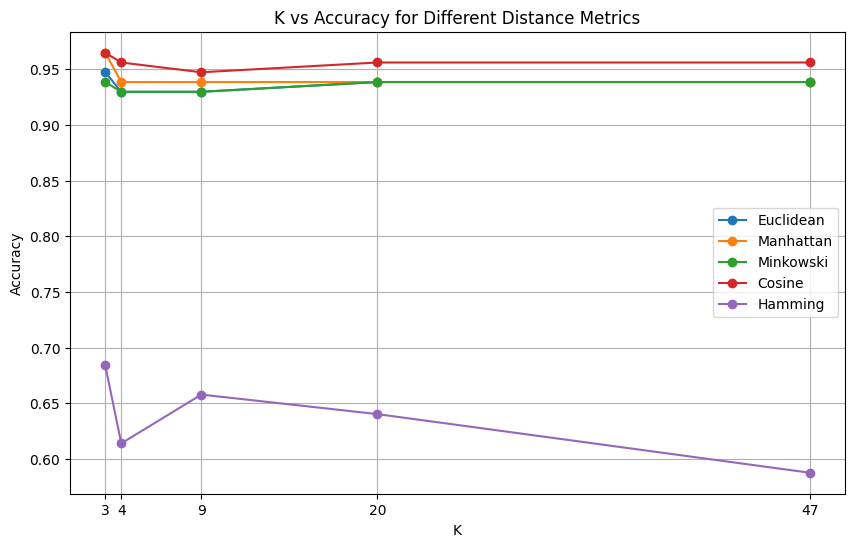

In [ ]:
plt.figure(figsize=(10, 6))

for metric in metrics:

    metric_data = results_df[
        results_df['Metric'] == metric
    ]

    plt.plot(
        metric_data['K'],
        metric_data['Accuracy'],
        marker='o',
        label=metric
    )

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy for Different Distance Metrics")

plt.xticks(k_values)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
best_k = int(best_result['K'])
best_metric = best_result['Metric']

best_predictions = knn_predict(
    X_train,
    y_train,
    X_test,
    best_k,
    best_metric
)

In [ ]:
def confusion_matrix(y_true, y_pred):

    TN = 0
    FP = 0
    FN = 0
    TP = 0

    for actual, predicted in zip(y_true, y_pred):

        if actual == 0 and predicted == 0:
            TN += 1

        elif actual == 0 and predicted == 1:
            FP += 1

        elif actual == 1 and predicted == 0:
            FN += 1

        elif actual == 1 and predicted == 1:
            TP += 1

    return np.array([
        [TN, FP],
        [FN, TP]
    ])

In [ ]:
cm = confusion_matrix(y_test, best_predictions)

print(cm)

[[67  0]
 [ 4 43]]


In [ ]:
TN, FP = cm[0]
FN, TP = cm[1]

precision = TP / (TP + FP)

print("Precision:", precision)

Precision: 1.0


In [ ]:
recall = TP / (TP + FN)

print("Recall:", recall)

Recall: 0.9148936170212766


In [ ]:
print("Best Distance:", best_metric)
print("Best K:", best_k)
print("Accuracy:", accuracy(y_test, best_predictions))
print("Precision:", precision)
print("Recall:", recall)

print("\nConfusion Matrix:")
print(cm)

Best Distance: Manhattan
Best K: 3
Accuracy: 0.9649122807017544
Precision: 1.0
Recall: 0.9148936170212766

Confusion Matrix:
[[67  0]
 [ 4 43]]
